# Transaction data simulator

In [185]:
import os

import numpy as np
import pandas as pd

import datetime
import time

import random

# For plotting
%matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sns

import sklearn

sns.set_style('darkgrid', {'axes.facecolor': '0.9'})

## Customer profiles generation 

### 1

In [3]:
def generate_customer_profiles_table(n_customers, random_state=0):
    
    np.random.seed(random_state)
        
    customer_id_properties=[]
    
    # Generate customer properties from random distributions 
    for customer_id in range(n_customers):
        
        x_customer_id = np.random.uniform(0,100)
        y_customer_id = np.random.uniform(0,100)
        
        mean_amount = np.random.uniform(5,100) 
        std_amount = mean_amount/2 
        
        mean_nb_tx_per_day = np.random.uniform(0,4) 
        
        customer_id_properties.append([customer_id,
                                      x_customer_id, y_customer_id,
                                      mean_amount, std_amount,
                                      mean_nb_tx_per_day])
        
    customer_profiles_table = pd.DataFrame(customer_id_properties, columns=['CUSTOMER_ID',
                                                                      'x_customer_id', 'y_customer_id',
                                                                      'mean_amount', 'std_amount',
                                                                      'mean_nb_tx_per_day'])
    
    return customer_profiles_table

### 2

In [ ]:
# def generate_customer_profiles_table(n_customers, random_state=0):
#     np.random.seed(random_state)
#     customer_id_properties = []
    
#     for customer_id in range(n_customers):
#         # Random location coordinates
#         x_customer_id = np.random.uniform(0, 100)
#         y_customer_id = np.random.uniform(0, 100)
        
#         # Mean transaction amount (log-normal for skewness)
#         mean_amount = np.random.lognormal(mean=3.4, sigma=0.5)
        
#         # Std based on coefficient of variation
#         cv = np.random.uniform(0.3, 0.6)
#         std_amount = mean_amount * cv
        
#         # Mean number of transactions/day (Gamma for positive skew)
#         mean_nb_tx_per_day = np.random.gamma(shape=2, scale=0.5)
        
#         customer_id_properties.append([
#             customer_id,
#             x_customer_id, y_customer_id,
#             mean_amount, std_amount,
#             mean_nb_tx_per_day
#         ])
    
#     customer_profiles_table = pd.DataFrame(
#         customer_id_properties,
#         columns=['CUSTOMER_ID', 'x_customer_id', 'y_customer_id',
#                  'mean_amount', 'std_amount', 'mean_nb_tx_per_day']
#     )
    
#     return customer_profiles_table


### 3 --> 2 transactions

In [ ]:
# def generate_customer_profiles_table(n_customers, random_state=0):
#     np.random.seed(random_state)

#     customer_id_properties = []

#     for customer_id in range(n_customers):
#         # Random customer location
#         x_customer_id = np.random.uniform(0, 100)
#         y_customer_id = np.random.uniform(0, 100)

#         # Mean and std for transaction amounts
#         mean_amount = np.random.uniform(5, 100)  # Mean transaction value
#         std_amount = mean_amount / 2  # Std deviation proportional to mean

#         # Clip std so it doesn't go crazy for very low/high means
#         std_amount = np.clip(std_amount, 1, mean_amount)

#         # Mean number of transactions per day
#         mean_nb_tx_per_day = np.random.uniform(0, 4)

#         # Clip transaction amounts dynamically based on mean ± 3 std
#         lower_bound = max(mean_amount - 3 * std_amount, 1)  # No negative amounts
#         upper_bound = mean_amount + 3 * std_amount

#         # Ensure bounds make sense
#         if upper_bound <= lower_bound:
#             upper_bound = lower_bound + std_amount

#         customer_id_properties.append([
#             customer_id,
#             x_customer_id, y_customer_id,
#             mean_amount, std_amount,
#             mean_nb_tx_per_day,
#             lower_bound, upper_bound
#         ])

#     # Create DataFrame
#     customer_profiles_table = pd.DataFrame(
#         customer_id_properties,
#         columns=[
#             'CUSTOMER_ID',
#             'x_customer_id', 'y_customer_id',
#             'mean_amount', 'std_amount',
#             'mean_nb_tx_per_day',
#             'min_tx_amount', 'max_tx_amount'
#         ]
#     )

#     return customer_profiles_table

## Terminal profiles generation

In [5]:
def generate_terminal_profiles_table(n_terminals, random_state=0):
    
    np.random.seed(random_state)
        
    terminal_id_properties=[]
    
    # Generate terminal properties from random distributions 
    for terminal_id in range(n_terminals):
        
        x_terminal_id = np.random.uniform(0,100)
        y_terminal_id = np.random.uniform(0,100)
        
        terminal_id_properties.append([terminal_id,
                                      x_terminal_id, y_terminal_id])
                                       
    terminal_profiles_table = pd.DataFrame(terminal_id_properties, columns=['TERMINAL_ID',
                                                                      'x_terminal_id', 'y_terminal_id'])
    
    return terminal_profiles_table

## Association of customer profiles to terminals

In [6]:
def get_list_terminals_within_radius(customer_profile, x_y_terminals, r):
    
    # Location (x,y) of customer as numpy array
    x_y_customer = customer_profile[['x_customer_id','y_customer_id']].values.astype(float)
    
    # Squared difference in coordinates between customer and terminal locations
    squared_diff_x_y = np.square(x_y_customer - x_y_terminals)
    
    # Sum along rows and compute suared root to get distance
    dist_x_y = np.sqrt(np.sum(squared_diff_x_y, axis=1))
    
    # Get the indices of terminals which are at a distance less than r
    available_terminals = list(np.where(dist_x_y<r)[0])
    
    
    return available_terminals

## Test

In [7]:
n_customers = 5
customer_profiles_table = generate_customer_profiles_table(n_customers, random_state = 0)
customer_profiles_table

,CUSTOMER_ID,x_customer_id,y_customer_id,mean_amount,std_amount,mean_nb_tx_per_day
0,0,54.881350,71.518937,62.262521,31.131260,2.179533
1,1,42.365480,64.589411,46.570785,23.285393,3.567092
2,2,96.366276,38.344152,80.213879,40.106939,2.115580
3,3,56.804456,92.559664,11.748426,5.874213,0.348517
4,4,2.021840,83.261985,78.924891,39.462446,3.480049


In [8]:
n_terminals = 5
terminal_profiles_table = generate_terminal_profiles_table(n_terminals, random_state = 0)
terminal_profiles_table

,TERMINAL_ID,x_terminal_id,y_terminal_id
0,0,54.881350,71.518937
1,1,60.276338,54.488318
2,2,42.365480,64.589411
3,3,43.758721,89.177300
4,4,96.366276,38.344152


In [9]:
# geographical locations of all terminals 
x_y_terminals = terminal_profiles_table[['x_terminal_id','y_terminal_id']].values.astype(float)

# list of terminals within radius of 50 for the last customer
get_list_terminals_within_radius(customer_profiles_table.iloc[4], x_y_terminals=x_y_terminals, r=50)

[np.int64(2), np.int64(3)]

In [10]:
%%capture

terminals_available_to_customer_fig, ax = plt.subplots(figsize=(5,5))

# Plot locations of terminals
ax.scatter(terminal_profiles_table.x_terminal_id.values, 
           terminal_profiles_table.y_terminal_id.values, 
           color='blue', label = 'Locations of terminals')

# Plot location of the last customer
customer_id=4
ax.scatter(customer_profiles_table.iloc[customer_id].x_customer_id, 
           customer_profiles_table.iloc[customer_id].y_customer_id, 
           color='red',label="Location of last customer")

ax.legend(loc = 'upper left', bbox_to_anchor=(1.05, 1))

# Plot the region within a radius of 50 of the last customer
circ = plt.Circle((customer_profiles_table.iloc[customer_id].x_customer_id,
                   customer_profiles_table.iloc[customer_id].y_customer_id), radius=50, color='g', alpha=0.2)
ax.add_patch(circ)

fontsize=15

ax.set_title("Green circle: \n Terminals within a radius of 50 \n of the last customer")
ax.set_xlim([0, 100])
ax.set_ylim([0, 100])
    
ax.set_xlabel('x_terminal_id', fontsize=fontsize)
ax.set_ylabel('y_terminal_id', fontsize=fontsize)

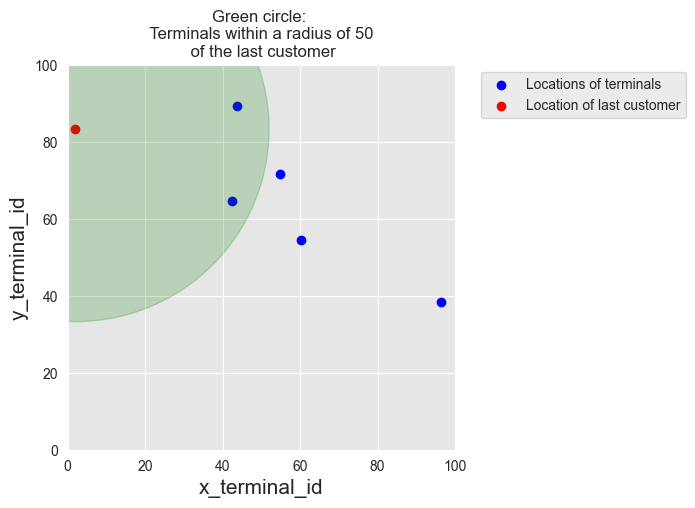

In [18]:
terminals_available_to_customer_fig

In [11]:
customer_profiles_table['available_terminals']=customer_profiles_table.apply(lambda x : get_list_terminals_within_radius(x, x_y_terminals=x_y_terminals, r=50), axis=1)
customer_profiles_table

,CUSTOMER_ID,x_customer_id,y_customer_id,mean_amount,std_amount,mean_nb_tx_per_day,available_terminals
0,0,54.881350,71.518937,62.262521,31.131260,2.179533,"[0, 1, 2, 3]"
1,1,42.365480,64.589411,46.570785,23.285393,3.567092,"[0, 1, 2, 3]"
2,2,96.366276,38.344152,80.213879,40.106939,2.115580,"[1, 4]"
3,3,56.804456,92.559664,11.748426,5.874213,0.348517,"[0, 1, 2, 3]"
4,4,2.021840,83.261985,78.924891,39.462446,3.480049,"[2, 3]"


## Generation of transactions

### 1

In [12]:
def generate_transactions_table(customer_profile, start_date = "2025-01-01", nb_days = 10):
    
    customer_transactions = []
    
    random.seed(int(customer_profile.CUSTOMER_ID))
    np.random.seed(int(customer_profile.CUSTOMER_ID))
    
    # For all days
    for day in range(nb_days):
        
        # Random number of transactions for that day 
        nb_tx = np.random.poisson(customer_profile.mean_nb_tx_per_day)
        
        # If nb_tx positive, let us generate transactions
        if nb_tx>0:
            
            for tx in range(nb_tx):
        
                # most transactions occur during the day.
                time_tx = int(np.random.normal(86400/2, 20000))
                
                # Only keep transactions that happen between midnight (0s) and 23:59:59 (86400s)
                if (time_tx>0) and (time_tx<86400):
                    
                    amount = np.random.normal(customer_profile.mean_amount, customer_profile.std_amount)
                    
                    # If amount negative, draw from a uniform distribution
                    if amount<0:
                        amount = np.random.uniform(0,customer_profile.mean_amount*2)
                    
                    amount=np.round(amount,decimals=2)
                    
                    if len(customer_profile.available_terminals)>0:
                        
                        terminal_id = random.choice(customer_profile.available_terminals)
                    
                        customer_transactions.append([time_tx+day*86400, day,
                                                      customer_profile.CUSTOMER_ID, 
                                                      terminal_id, amount])
            
    customer_transactions = pd.DataFrame(customer_transactions, columns=['TX_TIME_SECONDS', 'TX_TIME_DAYS', 'CUSTOMER_ID', 'TERMINAL_ID', 'TX_AMOUNT'])

    # Converts transaction time in seconds into an actual datetime, starting from start_date
    
    if len(customer_transactions)>0:
        customer_transactions['TX_DATETIME'] = pd.to_datetime(customer_transactions["TX_TIME_SECONDS"], unit='s', origin=start_date)
        customer_transactions=customer_transactions[['TX_DATETIME','CUSTOMER_ID', 'TERMINAL_ID', 'TX_AMOUNT','TX_TIME_SECONDS', 'TX_TIME_DAYS']]
    
    return customer_transactions  

### 2 <-- 3 customer 

In [ ]:
# def generate_transactions(customer_profiles, start_date, n_days, random_state=0):
#     np.random.seed(random_state)

#     transactions = []
#     transaction_id = 0

#     for _, row in customer_profiles.iterrows():
#         customer_id = row['CUSTOMER_ID']
#         mean_amount = row['mean_amount']
#         std_amount = row['std_amount']
#         mean_nb_tx_per_day = row['mean_nb_tx_per_day']
#         min_tx = row['min_tx_amount']
#         max_tx = row['max_tx_amount']

#         for day in range(n_days):
#             nb_tx = np.random.poisson(mean_nb_tx_per_day)

#             for _ in range(nb_tx):
#                 transaction_id += 1
#                 tx_date = start_date + timedelta(days=day,
#                                                  seconds=np.random.randint(0, 24*60*60))

#                 # Draw amount from normal dist then clip
#                 amount = np.random.normal(mean_amount, std_amount)
#                 amount = np.clip(amount, min_tx, max_tx)

#                 transactions.append([
#                     transaction_id,
#                     customer_id,
#                     tx_date,
#                     round(amount, 2)
#                 ])

#     transactions_df = pd.DataFrame(
#         transactions,
#         columns=['TRANSACTION_ID', 'CUSTOMER_ID', 'TX_DATETIME', 'TX_AMOUNT']
#     )

#     return transactions_df

## Test

In [13]:
transaction_table_customer_0=generate_transactions_table(customer_profiles_table.iloc[0], 
                                                         start_date = "2025-01-01", 
                                                         nb_days = 5)
transaction_table_customer_0

,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS
0,2025-01-01 07:19:05,0,3,123.59,26345,0
1,2025-01-01 19:02:02,0,3,46.51,68522,0
2,2025-01-01 18:00:16,0,0,77.34,64816,0
3,2025-01-02 15:13:02,0,2,32.35,141182,1
4,2025-01-02 14:05:38,0,3,63.30,137138,1
5,2025-01-02 15:46:51,0,3,13.59,143211,1
6,2025-01-02 08:51:06,0,2,54.72,118266,1
7,2025-01-02 20:24:47,0,3,51.89,159887,1
8,2025-01-03 12:15:47,0,2,117.91,216947,2
9,2025-01-03 08:50:09,0,1,67.72,204609,2


In [14]:
transactions_df=customer_profiles_table.groupby('CUSTOMER_ID').apply(lambda x : generate_transactions_table(x.iloc[0], nb_days=5)).reset_index(drop=True)
transactions_df

/var/folders/ft/s2jg9mtd4ml_jb315y5m66480000gn/T/ipykernel_39073/1082527515.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  transactions_df=customer_profiles_table.groupby('CUSTOMER_ID').apply(lambda x : generate_transactions_table(x.iloc[0], nb_days=5)).reset_index(drop=True)


,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS
0,2025-01-01 07:19:05,0,3,123.59,26345,0
1,2025-01-01 19:02:02,0,3,46.51,68522,0
2,2025-01-01 18:00:16,0,0,77.34,64816,0
3,2025-01-02 15:13:02,0,2,32.35,141182,1
4,2025-01-02 14:05:38,0,3,63.30,137138,1
...,...,...,...,...,...,...
60,2025-01-05 07:41:19,4,2,111.38,373279,4
61,2025-01-05 06:59:59,4,3,80.36,370799,4
62,2025-01-05 17:23:34,4,2,53.25,408214,4
63,2025-01-05 12:51:38,4,2,36.44,391898,4


## Scaling up to a larger dataset

In [22]:
def generate_dataset(n_customers = 10000, n_terminals = 1000000, nb_days=90, start_date="2025-01-01", r=5):
    
    customer_profiles_table = generate_customer_profiles_table(n_customers, random_state = 0)
    
    terminal_profiles_table = generate_terminal_profiles_table(n_terminals, random_state = 1)
    
    x_y_terminals = terminal_profiles_table[['x_terminal_id','y_terminal_id']].values.astype(float)
  
    customer_profiles_table['available_terminals'] = customer_profiles_table.apply(lambda x : get_list_terminals_within_radius(x, x_y_terminals=x_y_terminals, r=r), axis=1)
    customer_profiles_table['nb_terminals']=customer_profiles_table.available_terminals.apply(len)
   
    transactions_df=customer_profiles_table.groupby('CUSTOMER_ID').apply(lambda x : generate_transactions_table(x.iloc[0], nb_days=nb_days)).reset_index(drop=True)
   
    # Sort transactions chronologically
    transactions_df=transactions_df.sort_values('TX_DATETIME')

    # Reset indices, starting from 0
    transactions_df.reset_index(inplace=True,drop=True)
    transactions_df.reset_index(inplace=True)
    
    # TRANSACTION_ID are the dataframe indices, starting from 0
    transactions_df.rename(columns = {'index':'TRANSACTION_ID'}, inplace = True)
    
    return (customer_profiles_table, terminal_profiles_table, transactions_df)
    

In [23]:
(customer_profiles_table, terminal_profiles_table, transactions_df)=\
    generate_dataset(n_customers = 5000, 
                     n_terminals = 10000, 
                     nb_days=183, 
                     start_date="2025-01-01", 
                     r=5)

/var/folders/ft/s2jg9mtd4ml_jb315y5m66480000gn/T/ipykernel_39073/3586106454.py:12: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  transactions_df=customer_profiles_table.groupby('CUSTOMER_ID').apply(lambda x : generate_transactions_table(x.iloc[0], nb_days=nb_days)).reset_index(drop=True)
/var/folders/ft/s2jg9mtd4ml_jb315y5m66480000gn/T/ipykernel_39073/3586106454.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  transactions_df=customer_profiles_tab

In [24]:
transactions_df.shape

(1754155, 7)

In [25]:
transactions_df

,TRANSACTION_ID,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS
0,0,2025-01-01 00:00:31,596,3156,57.16,31,0
1,1,2025-01-01 00:02:10,4961,3412,81.51,130,0
2,2,2025-01-01 00:07:56,2,1365,146.00,476,0
3,3,2025-01-01 00:09:29,4128,8737,64.49,569,0
4,4,2025-01-01 00:10:34,927,9906,50.99,634,0
...,...,...,...,...,...,...,...
1754150,1754150,2025-07-02 23:56:36,161,655,54.24,15810996,182
1754151,1754151,2025-07-02 23:57:38,4342,6181,1.23,15811058,182
1754152,1754152,2025-07-02 23:58:21,618,1502,6.62,15811101,182
1754153,1754153,2025-07-02 23:59:52,4056,3067,55.40,15811192,182


In [26]:
%%capture

distribution_amount_times_fig, ax = plt.subplots(1, 2, figsize=(18,4))

amount_val = transactions_df[transactions_df.TX_TIME_DAYS<10]['TX_AMOUNT'].sample(n=10000).values
time_val = transactions_df[transactions_df.TX_TIME_DAYS<10]['TX_TIME_SECONDS'].sample(n=10000).values

sns.distplot(amount_val, ax=ax[0], color='r', hist = True, kde = False)
ax[0].set_title('Distribution of transaction amounts', fontsize=14)
ax[0].set_xlim([min(amount_val), max(amount_val)])
ax[0].set(xlabel = "Amount", ylabel="Number of transactions")

# We divide the time variables by 86400 to transform seconds to days in the plot
sns.distplot(time_val/86400, ax=ax[1], color='b', bins = 100, hist = True, kde = False)
ax[1].set_title('Distribution of transaction times', fontsize=14)
ax[1].set_xlim([min(time_val/86400), max(time_val/86400)])
ax[1].set_xticks(range(10))
ax[1].set(xlabel = "Time (days)", ylabel="Number of transactions")

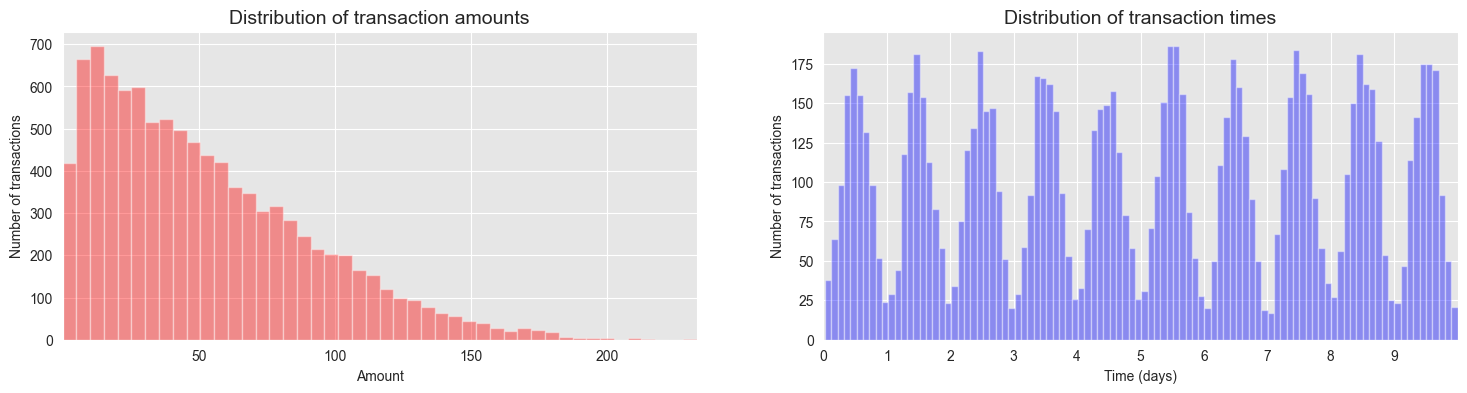

In [27]:
distribution_amount_times_fig

## Fraud scenarios generation

In [28]:
def add_frauds(customer_profiles_table, terminal_profiles_table, transactions_df):
    
    # By default, all transactions are genuine
    transactions_df['TX_FRAUD']=0
    transactions_df['TX_FRAUD_SCENARIO']=0
    
    # Scenario 1
    transactions_df.loc[transactions_df.TX_AMOUNT>220, 'TX_FRAUD']=1
    transactions_df.loc[transactions_df.TX_AMOUNT>220, 'TX_FRAUD_SCENARIO']=1
    nb_frauds_scenario_1=transactions_df.TX_FRAUD.sum()
    print("Number of frauds from scenario 1: "+str(nb_frauds_scenario_1))
    
    # Scenario 2
    for day in range(transactions_df.TX_TIME_DAYS.max()):
        
        compromised_terminals = terminal_profiles_table.TERMINAL_ID.sample(n=2, random_state=day)
        
        compromised_transactions=transactions_df[(transactions_df.TX_TIME_DAYS>=day) & 
                                                    (transactions_df.TX_TIME_DAYS<day+28) & 
                                                    (transactions_df.TERMINAL_ID.isin(compromised_terminals))]
                            
        transactions_df.loc[compromised_transactions.index,'TX_FRAUD']=1
        transactions_df.loc[compromised_transactions.index,'TX_FRAUD_SCENARIO']=2
    
    nb_frauds_scenario_2=transactions_df.TX_FRAUD.sum()-nb_frauds_scenario_1
    print("Number of frauds from scenario 2: "+str(nb_frauds_scenario_2))
    
    # Scenario 3
    for day in range(transactions_df.TX_TIME_DAYS.max()):
        
        compromised_customers = customer_profiles_table.CUSTOMER_ID.sample(n=3, random_state=day).values
        
        compromised_transactions=transactions_df[(transactions_df.TX_TIME_DAYS>=day) & 
                                                    (transactions_df.TX_TIME_DAYS<day+14) & 
                                                    (transactions_df.CUSTOMER_ID.isin(compromised_customers))]
        
        nb_compromised_transactions=len(compromised_transactions)
        
        
        random.seed(day)
        index_fauds = random.sample(list(compromised_transactions.index.values),k=int(nb_compromised_transactions/3))
        
        transactions_df.loc[index_fauds,'TX_AMOUNT']=transactions_df.loc[index_fauds,'TX_AMOUNT']*5
        transactions_df.loc[index_fauds,'TX_FRAUD']=1
        transactions_df.loc[index_fauds,'TX_FRAUD_SCENARIO']=3
        
                             
    nb_frauds_scenario_3=transactions_df.TX_FRAUD.sum()-nb_frauds_scenario_2-nb_frauds_scenario_1
    print("Number of frauds from scenario 3: "+str(nb_frauds_scenario_3))
    
    return transactions_df                 

In [30]:
transactions_df = add_frauds(customer_profiles_table, terminal_profiles_table, transactions_df)

Number of frauds from scenario 1: 3258
Number of frauds from scenario 2: 9091
Number of frauds from scenario 3: 2332


In [32]:
transactions_df.TX_FRAUD.mean()

np.float64(0.008369271814634397)

In [33]:
transactions_df.TX_FRAUD.sum()

np.int64(14681)

A total of 14681 transactions were marked as fraudulent. This amounts to 0.8% of the transactions. 
The sum of the frauds for each scenario does not equal the total amount of fraudulent transactions. This is because the same transactions may have been marked as fraudulent by two or more fraud scenarios.

In [34]:
transactions_df.head()

,TRANSACTION_ID,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO
0,0,2025-01-01 00:00:31,596,3156,57.16,31,0,0,0
1,1,2025-01-01 00:02:10,4961,3412,81.51,130,0,0,0
2,2,2025-01-01 00:07:56,2,1365,146.00,476,0,0,0
3,3,2025-01-01 00:09:29,4128,8737,64.49,569,0,0,0
4,4,2025-01-01 00:10:34,927,9906,50.99,634,0,0,0


In [35]:
transactions_df[transactions_df.TX_FRAUD_SCENARIO==1].shape

(4631, 9)

In [36]:
transactions_df[transactions_df.TX_FRAUD_SCENARIO==2].shape

(9077, 9)

In [37]:
transactions_df[transactions_df.TX_FRAUD_SCENARIO==3].shape

(4631, 9)

In [38]:
def get_stats(transactions_df):
    #Number of transactions per day
    nb_tx_per_day=transactions_df.groupby(['TX_TIME_DAYS'])['CUSTOMER_ID'].count()
    #Number of fraudulent transactions per day
    nb_fraud_per_day=transactions_df.groupby(['TX_TIME_DAYS'])['TX_FRAUD'].sum()
    #Number of fraudulent cards per day
    nb_fraudcard_per_day=transactions_df[transactions_df['TX_FRAUD']>0].groupby(['TX_TIME_DAYS']).CUSTOMER_ID.nunique()
    
    return (nb_tx_per_day,nb_fraud_per_day,nb_fraudcard_per_day)

(nb_tx_per_day,nb_fraud_per_day,nb_fraudcard_per_day)=get_stats(transactions_df)

n_days=len(nb_tx_per_day)
tx_stats=pd.DataFrame({"value":pd.concat([nb_tx_per_day/50,nb_fraud_per_day,nb_fraudcard_per_day])})
tx_stats['stat_type']=["nb_tx_per_day"]*n_days+["nb_fraud_per_day"]*n_days+["nb_fraudcard_per_day"]*n_days
tx_stats=tx_stats.reset_index()

In [39]:
%%capture

sns.set(style='darkgrid')
sns.set(font_scale=1.4)

fraud_and_transactions_stats_fig = plt.gcf()

fraud_and_transactions_stats_fig.set_size_inches(15, 8)

sns_plot = sns.lineplot(x="TX_TIME_DAYS", y="value", data=tx_stats, hue="stat_type", hue_order=["nb_tx_per_day","nb_fraud_per_day","nb_fraudcard_per_day"], legend=False)

sns_plot.set_title('Total transactions, and number of fraudulent transactions \n and number of compromised cards per day', fontsize=20)
sns_plot.set(xlabel = "Number of days since beginning of data generation", ylabel="Number")

sns_plot.set_ylim([0,300])

labels_legend = ["# transactions per day (/50)", "# fraudulent txs per day", "# fraudulent cards per day"]

sns_plot.legend(loc='upper left', labels=labels_legend,bbox_to_anchor=(1.05, 1), fontsize=15)

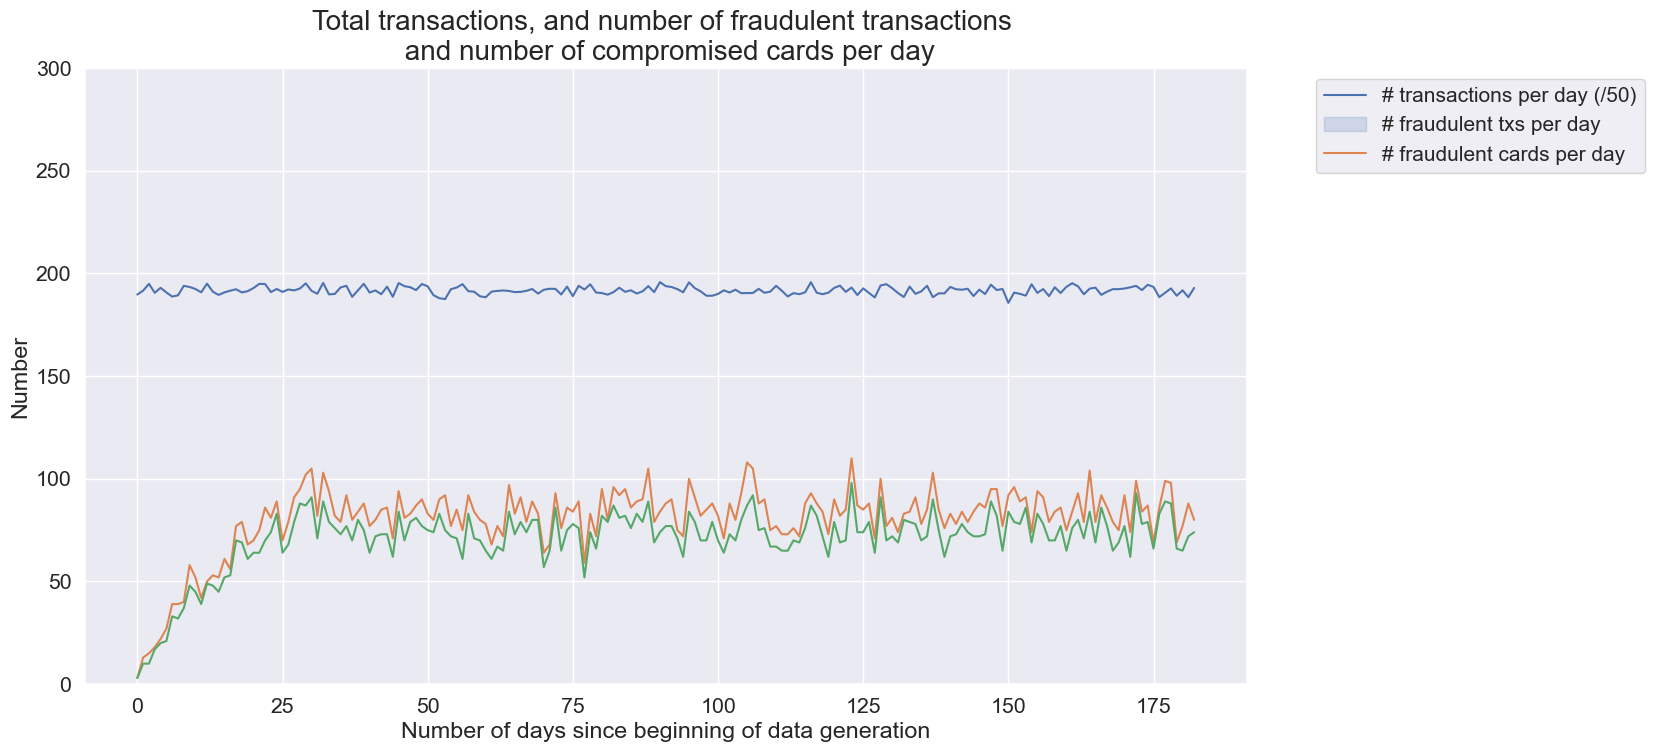

In [40]:
fraud_and_transactions_stats_fig

This simulation generated around 10000 transactions per day. The number of fraudulent transactions per day is around 85, and the number of fraudulent cards around 80. 
The first month has a lower number of fraudulent transactions, because frauds from scenarios 2 and 3 span periods of 28 and 14 days.

The resulting dataset features class imbalance (less than 1% of fraudulent transactions), a mix of numerical and categorical features, non-trivial relationships between features, and time-dependent fraud scenarios.

#  Feature transformation

##  Date and time transformations

In [41]:
def is_weekend(tx_datetime):
    
    # Transform date into weekday (0 is Monday, 6 is Sunday)
    weekday = tx_datetime.weekday()
    # Binary value: 0 if weekday, 1 if weekend
    is_weekend = weekday>=5
    
    return int(is_weekend)

In [42]:
transactions_df['TX_DURING_WEEKEND']=transactions_df.TX_DATETIME.apply(is_weekend)

In [43]:
def is_night(tx_datetime):
    
    # Get the hour of the transaction
    tx_hour = tx_datetime.hour
    # Binary value: 1 if hour less than 6, and 0 otherwise
    is_night = tx_hour<=6
    
    return int(is_night)

In [44]:
transactions_df['TX_DURING_NIGHT']=transactions_df.TX_DATETIME.apply(is_night)

In [45]:
transactions_df[transactions_df.TX_TIME_DAYS>=30]

,TRANSACTION_ID,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO,TX_DURING_WEEKEND,TX_DURING_NIGHT
288062,288062,2025-01-31 00:01:21,3546,2944,18.71,2592081,30,0,0,0,1
288063,288063,2025-01-31 00:01:48,206,3521,18.60,2592108,30,0,0,0,1
288064,288064,2025-01-31 00:02:22,2610,4470,66.67,2592142,30,0,0,0,1
288065,288065,2025-01-31 00:03:15,4578,1520,79.41,2592195,30,0,0,0,1
288066,288066,2025-01-31 00:03:51,1246,7809,52.08,2592231,30,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...
1754150,1754150,2025-07-02 23:56:36,161,655,54.24,15810996,182,0,0,0,0
1754151,1754151,2025-07-02 23:57:38,4342,6181,1.23,15811058,182,0,0,0,0
1754152,1754152,2025-07-02 23:58:21,618,1502,6.62,15811101,182,0,0,0,0
1754153,1754153,2025-07-02 23:59:52,4056,3067,55.40,15811192,182,0,0,0,0


## Customer ID transformations

 The first feature will be the number of transactions that occur within a time window (Frequency). 
 
 The second will be the average amount spent in these transactions (Monetary value). 
 
 The time windows will be set to one, seven, and thirty days. This will generate six new features.
 
 These time windows could later be optimized along with the models using a model selection procedure 

In [46]:
def get_customer_spending_behaviour_features(customer_transactions, windows_size_in_days=[1,7,30]):
    
    # order transactions chronologically
    customer_transactions=customer_transactions.sort_values('TX_DATETIME')
    
    # The transaction date and time is set as the index, which will allow the use of the rolling function 
    customer_transactions.index=customer_transactions.TX_DATETIME
    
    for window_size in windows_size_in_days:
        
        # Compute the sum of the transaction amounts and the number of transactions for the given window size
        SUM_AMOUNT_TX_WINDOW=customer_transactions['TX_AMOUNT'].rolling(str(window_size)+'d').sum()
        NB_TX_WINDOW=customer_transactions['TX_AMOUNT'].rolling(str(window_size)+'d').count()
    
        # Compute the average transaction amount for the given window size
        # NB_TX_WINDOW is always >0 since current transaction is always included
        AVG_AMOUNT_TX_WINDOW=SUM_AMOUNT_TX_WINDOW/NB_TX_WINDOW
    
        customer_transactions['CUSTOMER_ID_NB_TX_'+str(window_size)+'DAY_WINDOW']=list(NB_TX_WINDOW)
        customer_transactions['CUSTOMER_ID_AVG_AMOUNT_'+str(window_size)+'DAY_WINDOW']=list(AVG_AMOUNT_TX_WINDOW)
    
    # Reindex according to transaction IDs
    customer_transactions.index=customer_transactions.TRANSACTION_ID
        
    return customer_transactions

In [47]:
spending_behaviour_customer_0=get_customer_spending_behaviour_features(transactions_df[transactions_df.CUSTOMER_ID==0])
spending_behaviour_customer_0

,TRANSACTION_ID,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO,TX_DURING_WEEKEND,TX_DURING_NIGHT,CUSTOMER_ID_NB_TX_1DAY_WINDOW,CUSTOMER_ID_AVG_AMOUNT_1DAY_WINDOW,CUSTOMER_ID_NB_TX_7DAY_WINDOW,CUSTOMER_ID_AVG_AMOUNT_7DAY_WINDOW,CUSTOMER_ID_NB_TX_30DAY_WINDOW,CUSTOMER_ID_AVG_AMOUNT_30DAY_WINDOW
TRANSACTION_ID,,,,,,,,,,,,,,,,,
1758,1758,2025-01-01 07:19:05,0,6076,123.59,26345,0,0,0,0,0,1.0,123.590000,1.0,123.590000,1.0,123.590000
8275,8275,2025-01-01 18:00:16,0,858,77.34,64816,0,0,0,0,0,2.0,100.465000,2.0,100.465000,2.0,100.465000
8640,8640,2025-01-01 19:02:02,0,6698,46.51,68522,0,0,0,0,0,3.0,82.480000,3.0,82.480000,3.0,82.480000
12169,12169,2025-01-02 08:51:06,0,6569,54.72,118266,1,0,0,0,0,3.0,59.523333,4.0,75.540000,4.0,75.540000
15764,15764,2025-01-02 14:05:38,0,7707,63.30,137138,1,0,0,0,0,4.0,60.467500,5.0,73.092000,5.0,73.092000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1750390,1750390,2025-07-02 13:38:41,0,3096,38.23,15773921,182,0,0,0,0,5.0,64.388000,28.0,57.306429,89.0,63.097640
1750758,1750758,2025-07-02 14:10:21,0,9441,43.60,15775821,182,0,0,0,0,6.0,60.923333,29.0,56.833793,89.0,62.433933
1751039,1751039,2025-07-02 14:34:30,0,1138,69.69,15777270,182,0,0,0,0,7.0,62.175714,29.0,57.872414,90.0,62.514556


In [48]:
transactions_df=transactions_df.groupby('CUSTOMER_ID').apply(lambda x: get_customer_spending_behaviour_features(x, windows_size_in_days=[1,7,30]))
transactions_df=transactions_df.sort_values('TX_DATETIME').reset_index(drop=True)

/var/folders/ft/s2jg9mtd4ml_jb315y5m66480000gn/T/ipykernel_39073/2557592315.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  transactions_df=transactions_df.groupby('CUSTOMER_ID').apply(lambda x: get_customer_spending_behaviour_features(x, windows_size_in_days=[1,7,30]))


In [49]:
transactions_df

,TRANSACTION_ID,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO,TX_DURING_WEEKEND,TX_DURING_NIGHT,CUSTOMER_ID_NB_TX_1DAY_WINDOW,CUSTOMER_ID_AVG_AMOUNT_1DAY_WINDOW,CUSTOMER_ID_NB_TX_7DAY_WINDOW,CUSTOMER_ID_AVG_AMOUNT_7DAY_WINDOW,CUSTOMER_ID_NB_TX_30DAY_WINDOW,CUSTOMER_ID_AVG_AMOUNT_30DAY_WINDOW
0,0,2025-01-01 00:00:31,596,3156,57.16,31,0,0,0,0,1,1.0,57.160000,1.0,57.160000,1.0,57.160000
1,1,2025-01-01 00:02:10,4961,3412,81.51,130,0,0,0,0,1,1.0,81.510000,1.0,81.510000,1.0,81.510000
2,2,2025-01-01 00:07:56,2,1365,146.00,476,0,0,0,0,1,1.0,146.000000,1.0,146.000000,1.0,146.000000
3,3,2025-01-01 00:09:29,4128,8737,64.49,569,0,0,0,0,1,1.0,64.490000,1.0,64.490000,1.0,64.490000
4,4,2025-01-01 00:10:34,927,9906,50.99,634,0,0,0,0,1,1.0,50.990000,1.0,50.990000,1.0,50.990000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1754150,1754150,2025-07-02 23:56:36,161,655,54.24,15810996,182,0,0,0,0,2.0,75.280000,12.0,67.047500,72.0,69.521111
1754151,1754151,2025-07-02 23:57:38,4342,6181,1.23,15811058,182,0,0,0,0,1.0,1.230000,21.0,22.173810,93.0,24.780753
1754152,1754152,2025-07-02 23:58:21,618,1502,6.62,15811101,182,0,0,0,0,5.0,7.368000,21.0,7.400476,65.0,7.864462
1754153,1754153,2025-07-02 23:59:52,4056,3067,55.40,15811192,182,0,0,0,0,3.0,100.696667,16.0,107.052500,51.0,102.919608


## Terminal ID transformations

The main goal will be to extract a risk score, that assesses the exposure of a given terminal ID to fraudulent transactions. 

The risk score will be defined as the average number of fraudulent transactions that occurred on a terminal ID over a time window. 

As for customer ID transformations, window sizes will be 1, 7, and 30 days.

The problem is to compute this risk score, we should look at past transactions that happened at the same terminal within a time window (e.g., past 7 days) and count how many were fraudulent. 

In real life, we don’t instantly know which transactions are fraudulent. Fraud is often discovered after a delay. 

If we calculate the risk score using transactions right up to the current moment (including those that will later be labeled fraud), we are accidentally using future information that wouldn’t be available at prediction time.

So we will face data leakage.

In [51]:
def get_count_risk_rolling_window(terminal_transactions, delay_period=7, windows_size_in_days=[1,7,30], feature="TERMINAL_ID"):
    
    terminal_transactions=terminal_transactions.sort_values('TX_DATETIME')
    
    terminal_transactions.index=terminal_transactions.TX_DATETIME
    
    NB_FRAUD_DELAY=terminal_transactions['TX_FRAUD'].rolling(str(delay_period)+'d').sum()
    NB_TX_DELAY=terminal_transactions['TX_FRAUD'].rolling(str(delay_period)+'d').count()
    
    for window_size in windows_size_in_days:
    
        NB_FRAUD_DELAY_WINDOW=terminal_transactions['TX_FRAUD'].rolling(str(delay_period+window_size)+'d').sum()
        NB_TX_DELAY_WINDOW=terminal_transactions['TX_FRAUD'].rolling(str(delay_period+window_size)+'d').count()
    
        NB_FRAUD_WINDOW=NB_FRAUD_DELAY_WINDOW-NB_FRAUD_DELAY
        NB_TX_WINDOW=NB_TX_DELAY_WINDOW-NB_TX_DELAY
    
        RISK_WINDOW=NB_FRAUD_WINDOW/NB_TX_WINDOW
        
        terminal_transactions[feature+'_NB_TX_'+str(window_size)+'DAY_WINDOW']=list(NB_TX_WINDOW)
        terminal_transactions[feature+'_RISK_'+str(window_size)+'DAY_WINDOW']=list(RISK_WINDOW)
        
    terminal_transactions.index=terminal_transactions.TRANSACTION_ID
    
    # Replace NA values with 0 (all undefined risk scores where NB_TX_WINDOW is 0) 
    terminal_transactions.fillna(0,inplace=True)
    
    return terminal_transactions

In [53]:
transactions_df=transactions_df.groupby('TERMINAL_ID').apply(lambda x: get_count_risk_rolling_window(x, delay_period=7, windows_size_in_days=[1,7,30], feature="TERMINAL_ID"))
transactions_df=transactions_df.sort_values('TX_DATETIME').reset_index(drop=True)

/var/folders/ft/s2jg9mtd4ml_jb315y5m66480000gn/T/ipykernel_39073/3343801630.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  transactions_df=transactions_df.groupby('TERMINAL_ID').apply(lambda x: get_count_risk_rolling_window(x, delay_period=7, windows_size_in_days=[1,7,30], feature="TERMINAL_ID"))


In [54]:
transactions_df

,TRANSACTION_ID,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO,TX_DURING_WEEKEND,...,CUSTOMER_ID_NB_TX_7DAY_WINDOW,CUSTOMER_ID_AVG_AMOUNT_7DAY_WINDOW,CUSTOMER_ID_NB_TX_30DAY_WINDOW,CUSTOMER_ID_AVG_AMOUNT_30DAY_WINDOW,TERMINAL_ID_NB_TX_1DAY_WINDOW,TERMINAL_ID_RISK_1DAY_WINDOW,TERMINAL_ID_NB_TX_7DAY_WINDOW,TERMINAL_ID_RISK_7DAY_WINDOW,TERMINAL_ID_NB_TX_30DAY_WINDOW,TERMINAL_ID_RISK_30DAY_WINDOW
0,0,2025-01-01 00:00:31,596,3156,57.16,31,0,0,0,0,...,1.0,57.160000,1.0,57.160000,0.0,0.0,0.0,0.0,0.0,0.00000
1,1,2025-01-01 00:02:10,4961,3412,81.51,130,0,0,0,0,...,1.0,81.510000,1.0,81.510000,0.0,0.0,0.0,0.0,0.0,0.00000
2,2,2025-01-01 00:07:56,2,1365,146.00,476,0,0,0,0,...,1.0,146.000000,1.0,146.000000,0.0,0.0,0.0,0.0,0.0,0.00000
3,3,2025-01-01 00:09:29,4128,8737,64.49,569,0,0,0,0,...,1.0,64.490000,1.0,64.490000,0.0,0.0,0.0,0.0,0.0,0.00000
4,4,2025-01-01 00:10:34,927,9906,50.99,634,0,0,0,0,...,1.0,50.990000,1.0,50.990000,0.0,0.0,0.0,0.0,0.0,0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1754150,1754150,2025-07-02 23:56:36,161,655,54.24,15810996,182,0,0,0,...,12.0,67.047500,72.0,69.521111,1.0,0.0,4.0,0.0,28.0,0.00000
1754151,1754151,2025-07-02 23:57:38,4342,6181,1.23,15811058,182,0,0,0,...,21.0,22.173810,93.0,24.780753,1.0,0.0,9.0,0.0,39.0,0.00000
1754152,1754152,2025-07-02 23:58:21,618,1502,6.62,15811101,182,0,0,0,...,21.0,7.400476,65.0,7.864462,1.0,0.0,5.0,0.0,33.0,0.00000
1754153,1754153,2025-07-02 23:59:52,4056,3067,55.40,15811192,182,0,0,0,...,16.0,107.052500,51.0,102.919608,1.0,0.0,6.0,0.0,28.0,0.00000


## Scailing data

In [186]:
from sklearn.preprocessing import StandardScaler

def scaleData(train_df, test_df, input_features):
    scaler = StandardScaler()
    # Fit only on training data
    train_df[input_features] = scaler.fit_transform(train_df[input_features])
    # Apply the same transform to test data
    test_df[input_features] = scaler.transform(test_df[input_features])
    return train_df, test_df


# Fraud detection system

## Picking a shortened window

To reduce runtime during prototyping, we can use a window of our dataframe. 

Here we use a 21-day window cause:
   
    1- It is short enough to drastically reduce runtime during prototyping
    
    2- It keeps the chronological order intact (train before test), which prevents data leakage
    
    3- Many fraud-monitoring cycles are weekly or biweekly. A 21-day (3-week) window captures multiple weekly patterns.

In [108]:
def count_frauds_in_window(df, start, days=21):
    s = pd.to_datetime(start)
    e = s + pd.Timedelta(days=days)
    sub = df[(df['TX_DATETIME'] >= s) & (df['TX_DATETIME'] < e)]
    return {'start': s, 'end': e, 'n_rows': len(sub), 'n_frauds': int(sub['TX_FRAUD'].sum()), 'fraud_rate': sub['TX_FRAUD'].mean()}

# Basic single-window
info = count_frauds_in_window(transactions_df, '2025-01-01', days=21)
print(info)

{'start': Timestamp('2025-01-01 00:00:00'), 'end': Timestamp('2025-01-22 00:00:00'), 'n_rows': 201256, 'n_frauds': 934, 'fraud_rate': np.float64(0.004640855427912708)}


In [109]:
# Stability: sample multiple 21-day windows every 30 days
def sample_windows(df, days=21, step=30):
    min_d = df['TX_DATETIME'].min().normalize()
    max_d = df['TX_DATETIME'].max().normalize()
    starts = []
    s = min_d
    while s + pd.Timedelta(days=days) <= max_d:
        starts.append(s)
        s += pd.Timedelta(days=step)
    return [count_frauds_in_window(df, st, days) for st in starts]

samples = sample_windows(transactions_df, days=21, step=30)
pd.DataFrame(samples)

,start,end,n_rows,n_frauds,fraud_rate
0,2025-01-01,2025-01-22,201256,934,0.004641
1,2025-01-31,2025-02-21,201860,1806,0.008947
2,2025-03-02,2025-03-23,201107,1686,0.008384
3,2025-04-01,2025-04-22,201441,1812,0.008995
4,2025-05-01,2025-05-22,201236,1798,0.008935
5,2025-05-31,2025-06-21,201125,1814,0.009019


We used a 21-day window (after Jan 31) cause it gives enough transactions (~200k) while keeping fraud rates stable.  
Fraud rate is unusually low in early January (≈0.46%) but stabilizes around ≈0.9% after late January,  
so we pick a window starting after Jan 31 to train on representative data.

## Defining the training and test sets

In [115]:
# Compute the number of transactions per day, fraudulent transactions per day and fraudulent cards per day

def get_tx_stats(transactions_df, start_date_df="2025-01-01"):
    
    #Number of transactions per day
    nb_tx_per_day=transactions_df.groupby(['TX_TIME_DAYS'])['CUSTOMER_ID'].count()
    #Number of fraudulent transactions per day
    nb_fraudulent_transactions_per_day=transactions_df.groupby(['TX_TIME_DAYS'])['TX_FRAUD'].sum()
    #Number of compromised cards per day
    nb_compromised_cards_per_day=transactions_df[transactions_df['TX_FRAUD']==1].groupby(['TX_TIME_DAYS']).CUSTOMER_ID.nunique()
    
    tx_stats=pd.DataFrame({"nb_tx_per_day":nb_tx_per_day,
                           "nb_fraudulent_transactions_per_day":nb_fraudulent_transactions_per_day,
                           "nb_compromised_cards_per_day":nb_compromised_cards_per_day})

    tx_stats=tx_stats.reset_index()
    
    start_date = datetime.datetime.strptime(start_date_df, "%Y-%m-%d")
    tx_date=start_date+tx_stats['TX_TIME_DAYS'].apply(datetime.timedelta)
    
    tx_stats['tx_date']=tx_date
    
    return tx_stats

tx_stats=get_tx_stats(transactions_df, start_date_df="2025-01-01")

To pick the best split we should look at two things:

1-Data Distribution:

    Does the train set cover enough fraud cases to learn meaningful patterns?

    Does the test set have enough fraud cases to make your metrics reliable?

2-Model Performance Stability:

    Underfitting and over fitting

In [116]:
%%capture

# Plot the number of transactions per day, fraudulent transactions per day and fraudulent cards per day

def get_template_tx_stats(ax ,fs,
                          start_date_training,
                          title='',
                          delta_train=90,
                          delta_delay=14,
                          delta_test=60,
                          ylim=300):
    
    ax.set_title(title, fontsize=fs*1.5)
    ax.set_ylim([0, ylim])
    
    ax.set_xlabel('Date', fontsize=fs)
    ax.set_ylabel('Number', fontsize=fs)
    
    plt.yticks(fontsize=fs*0.7) 
    plt.xticks(fontsize=fs*0.7)    

    ax.axvline(start_date_training+datetime.timedelta(days=delta_train), 0,ylim, color="black")
    ax.axvline(start_date_test, 0, ylim, color="black")

    ax.axvspan(start_date_training, start_date_training+datetime.timedelta(days=delta_train), alpha=0.3, color="green", label="Train")
    ax.axvspan(start_date_training+datetime.timedelta(days=delta_train), start_date_training+datetime.timedelta(days=delta_train+delta_delay), alpha=0.3, color="yellow", label="Delay")
    ax.axvspan(start_date_training+datetime.timedelta(days=delta_train+delta_delay), start_date_training+datetime.timedelta(days=delta_train+delta_delay+delta_test), alpha=0.3, color="red", label="Test")



cmap = plt.get_cmap('jet')
colors={'nb_tx_per_day':cmap(0), 
        'nb_fraudulent_transactions_per_day':cmap(200), 
        'nb_compromised_cards_per_day':cmap(250)}

fraud_and_transactions_stats_fig, ax = plt.subplots(1, 1, figsize=(15,8))

# Training period
start_date_training = datetime.datetime.strptime("2025-01-01", "%Y-%m-%d")
delta_train = 90
delta_delay = 14
delta_test = 60

end_date_training = start_date_training+datetime.timedelta(days=delta_train-1)

# Test period
start_date_test = start_date_training+datetime.timedelta(days=delta_train+delta_delay)
end_date_test = start_date_training+datetime.timedelta(days=delta_train+delta_delay+delta_test-1)

get_template_tx_stats(ax, fs=20,
                      start_date_training=start_date_training,
                      title='Total transactions, and number of fraudulent transactions \n and number of compromised cards per day',
                      delta_train=delta_train,
                      delta_delay=delta_delay,
                      delta_test=delta_test
                     )

ax.plot(tx_stats['tx_date'], tx_stats['nb_tx_per_day']/50, 'b', color=colors['nb_tx_per_day'], label = '# transactions per day (/50)')
ax.plot(tx_stats['tx_date'], tx_stats['nb_fraudulent_transactions_per_day'], 'b', color=colors['nb_fraudulent_transactions_per_day'], label = '# fraudulent txs per day')
ax.plot(tx_stats['tx_date'], tx_stats['nb_compromised_cards_per_day'], 'b', color=colors['nb_compromised_cards_per_day'], label = '# compromised cards per day')

ax.legend(loc = 'upper left',bbox_to_anchor=(1.05, 1),fontsize=20)

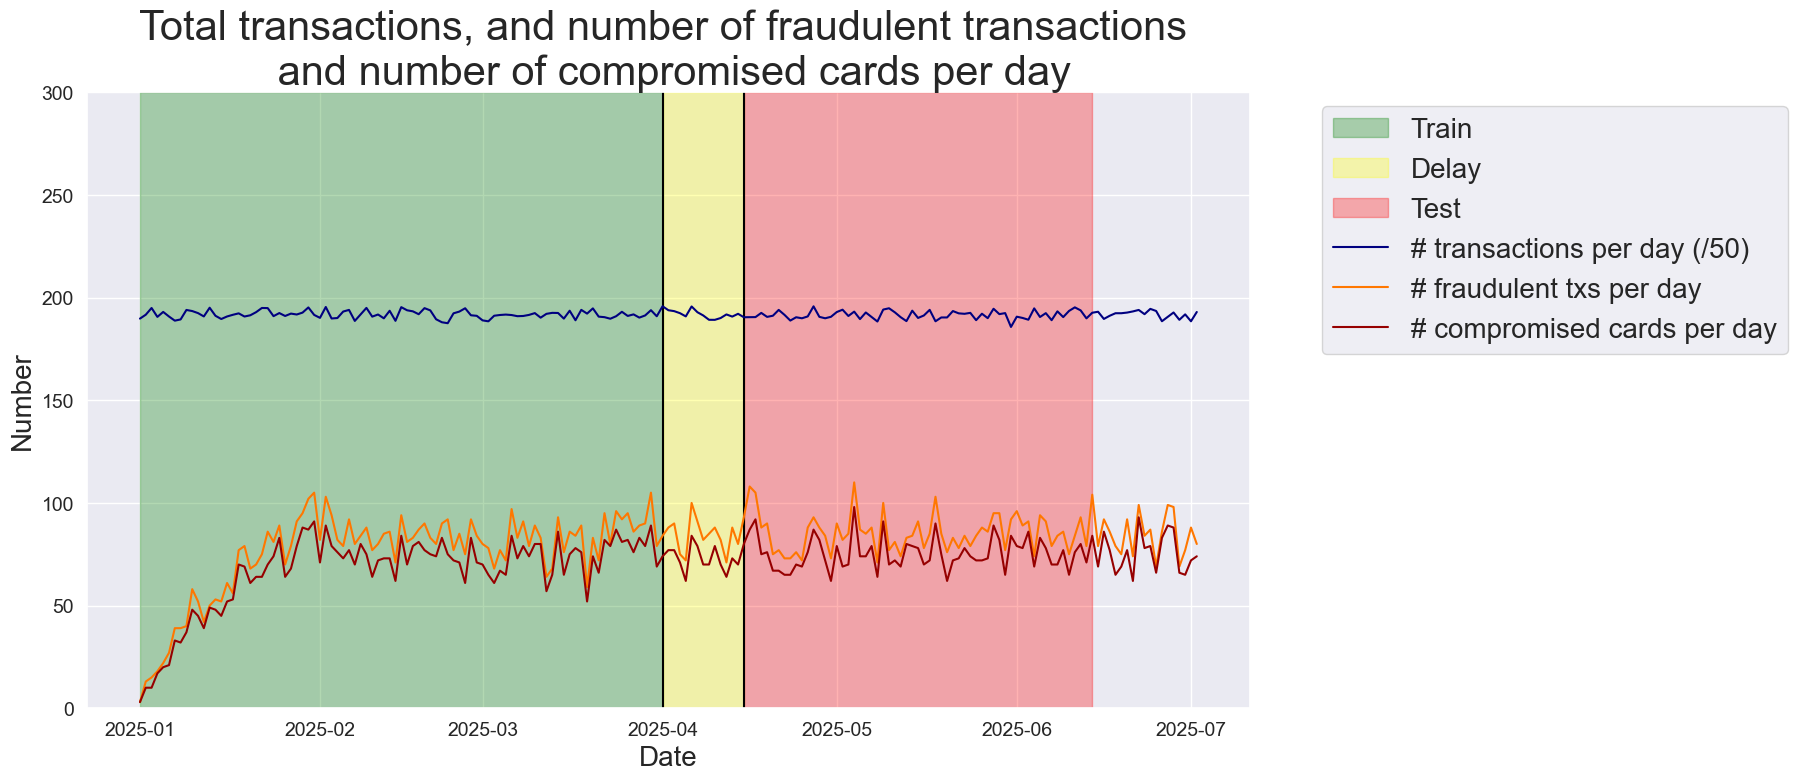

In [117]:
fraud_and_transactions_stats_fig

The plot illustrates that the number of transactions and frauds is similar in the training and test periods.

In [118]:
def get_train_test_set(transactions_df,
                       start_date_training,
                       delta_train=90,delta_delay=14,delta_test=60):
    
    train_df = transactions_df[(transactions_df.TX_DATETIME>=start_date_training) &
                               (transactions_df.TX_DATETIME<start_date_training+datetime.timedelta(days=delta_train))]
    
    test_df = []
    
    # Cards known to be compromised after the delay period are removed from the test set
    # That is, for each test day, all frauds known at (test_day-delay_period) are removed
    
    #  Defrauded customers from the training set
    known_defrauded_customers = set(train_df[train_df.TX_FRAUD==1].CUSTOMER_ID)
    
    # Get the relative starting day of training set (easier than TX_DATETIME to collect test data)
    start_tx_time_days_training = train_df.TX_TIME_DAYS.min()
    
    # Then, for each day of the test set
    for day in range(delta_test):
    
        # Get test data for that day
        test_df_day = transactions_df[transactions_df.TX_TIME_DAYS==start_tx_time_days_training+
                                                                    delta_train+delta_delay+
                                                                    day]
        
        # Compromised cards from that test day, minus the delay period, are added to the pool of known defrauded customers
        test_df_day_delay_period = transactions_df[transactions_df.TX_TIME_DAYS==start_tx_time_days_training+
                                                                                delta_train+
                                                                                day-1]
        
        new_defrauded_customers = set(test_df_day_delay_period[test_df_day_delay_period.TX_FRAUD==1].CUSTOMER_ID)
        known_defrauded_customers = known_defrauded_customers.union(new_defrauded_customers)
        
        test_df_day = test_df_day[~test_df_day.CUSTOMER_ID.isin(known_defrauded_customers)]
        
        test_df.append(test_df_day)
        
    test_df = pd.concat(test_df)
    
    # Sort data sets by ascending order of transaction ID
    train_df=train_df.sort_values('TRANSACTION_ID')
    test_df=test_df.sort_values('TRANSACTION_ID')
    
    return (train_df, test_df)

In [119]:
(train_df, test_df)=get_train_test_set(transactions_df,start_date_training,
                                       delta_train=90,delta_delay=14,delta_test=60)

In [ ]:
train_df.shape

(6761, 23)

In [121]:
train_df[train_df.TX_FRAUD==1].shape

(6761, 23)

In [122]:
test_df.shape

(203125, 23)

In [123]:
test_df[test_df.TX_FRAUD==1].shape

(1581, 23)

### Proportion of fraudulent transactions

In [124]:
test_df[test_df.TX_FRAUD==1].shape[0]/test_df.shape[0]

0.007783384615384616

## Model training : Decision tree

In [126]:
output_feature="TX_FRAUD"

# All the features that were computed in Feature transformation section
input_features=['TX_AMOUNT','TX_DURING_WEEKEND', 'TX_DURING_NIGHT', 'CUSTOMER_ID_NB_TX_1DAY_WINDOW',
       'CUSTOMER_ID_AVG_AMOUNT_1DAY_WINDOW', 'CUSTOMER_ID_NB_TX_7DAY_WINDOW',
       'CUSTOMER_ID_AVG_AMOUNT_7DAY_WINDOW', 'CUSTOMER_ID_NB_TX_30DAY_WINDOW',
       'CUSTOMER_ID_AVG_AMOUNT_30DAY_WINDOW', 'TERMINAL_ID_NB_TX_1DAY_WINDOW',
       'TERMINAL_ID_RISK_1DAY_WINDOW', 'TERMINAL_ID_NB_TX_7DAY_WINDOW',
       'TERMINAL_ID_RISK_7DAY_WINDOW', 'TERMINAL_ID_NB_TX_30DAY_WINDOW',
       'TERMINAL_ID_RISK_30DAY_WINDOW']

In [164]:
def fit_model_and_get_predictions(classifier, train_df, test_df, 
                                  input_features, output_feature="TX_FRAUD",scale=True):

    # Tree-based models (like Random Forest, XGBoost, or Decision Trees), because they are not sensitive to feature scaling.
    # However, for models like Logistic Regression, SVMs, or Neural Networks, scaling is important
    
    if scale and not isinstance(classifier, 
                                (sklearn.tree.DecisionTreeClassifier, 
                                 sklearn.ensemble.RandomForestClassifier,
                                 sklearn.ensemble.GradientBoostingClassifier)):
        (train_df, test_df) = scaleData(train_df, test_df, input_features)


    start_time=time.time() 
    classifier.fit(train_df[input_features], train_df[output_feature])
    training_execution_time=time.time()-start_time

    start_time=time.time()
    predictions_test=classifier.predict_proba(test_df[input_features])[:,1]
    prediction_execution_time=time.time()-start_time
    
    predictions_train=classifier.predict_proba(train_df[input_features])[:,1]


    model_and_predictions_dictionary = {'classifier': classifier,
                                        'predictions_test': predictions_test,
                                        'predictions_train': predictions_train,
                                        'training_execution_time': training_execution_time,
                                        'prediction_execution_time': prediction_execution_time
                                       }
    
    return model_and_predictions_dictionary

In [172]:
# # We first create a decision tree object. We limited its depth to 2 for interpretability, and set the random state to zero for reproducibility
# classifier = sklearn.tree.DecisionTreeClassifier(max_depth = 2, random_state=0)

# model_and_predictions_dictionary = fit_model_and_get_predictions(classifier, train_df, test_df, 
#                                                                  input_features, output_feature,
#                                                                  scale=False)

In [173]:
# test_df['TX_FRAUD_PREDICTED']=model_and_predictions_dictionary['predictions_test']
# test_df.head()

In [174]:
# from sklearn import tree

# plt.figure(figsize=(20,10)) 
# tree.plot_tree(
#     classifier, 
#     feature_names=input_features, 
#     class_names=True,  
#     filled=True, 
#     rounded=True,
#     fontsize=12
# )
# plt.show()


In [175]:
classifier = sklearn.tree.DecisionTreeClassifier(
    max_depth=3,         # limit depth so the tree doesn’t grow too much
    min_samples_leaf=100, # ensure each leaf has at least 100 samples
    random_state=0
 )

model_and_predictions_dictionary = fit_model_and_get_predictions(classifier, train_df, test_df, 
                                                                 input_features, output_feature,
                                                                 scale=False)

In [176]:
test_df['TX_FRAUD_PREDICTED']=model_and_predictions_dictionary['predictions_test']
test_df.head()

,TRANSACTION_ID,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO,TX_DURING_WEEKEND,...,CUSTOMER_ID_NB_TX_30DAY_WINDOW,CUSTOMER_ID_AVG_AMOUNT_30DAY_WINDOW,TERMINAL_ID_NB_TX_1DAY_WINDOW,TERMINAL_ID_RISK_1DAY_WINDOW,TERMINAL_ID_NB_TX_7DAY_WINDOW,TERMINAL_ID_RISK_7DAY_WINDOW,TERMINAL_ID_NB_TX_30DAY_WINDOW,TERMINAL_ID_RISK_30DAY_WINDOW,TX_FRAUD_PREDICTED,predictions
997463,997463,2025-04-15 00:01:19,993,7766,13.97,8985679,104,0,0,0,...,86.0,14.777558,0.0,0.0,5.0,0.0,20.0,0.0,0.00191,0.002221
997464,997464,2025-04-15 00:02:20,151,7058,7.06,8985740,104,0,0,0,...,35.0,28.254286,2.0,0.0,10.0,0.0,30.0,0.0,0.00191,0.002221
997466,997466,2025-04-15 00:03:47,3508,5196,9.16,8985827,104,0,0,0,...,43.0,7.787209,1.0,0.0,5.0,0.0,27.0,0.0,0.00191,0.002221
997468,997468,2025-04-15 00:05:15,1359,6986,7.88,8985915,104,0,0,0,...,79.0,7.294177,0.0,0.0,6.0,0.0,20.0,0.0,0.00191,0.002221
997470,997470,2025-04-15 00:07:03,4616,2787,95.68,8986023,104,0,0,0,...,30.0,58.623333,2.0,0.0,8.0,0.0,46.0,0.0,0.00191,0.002221


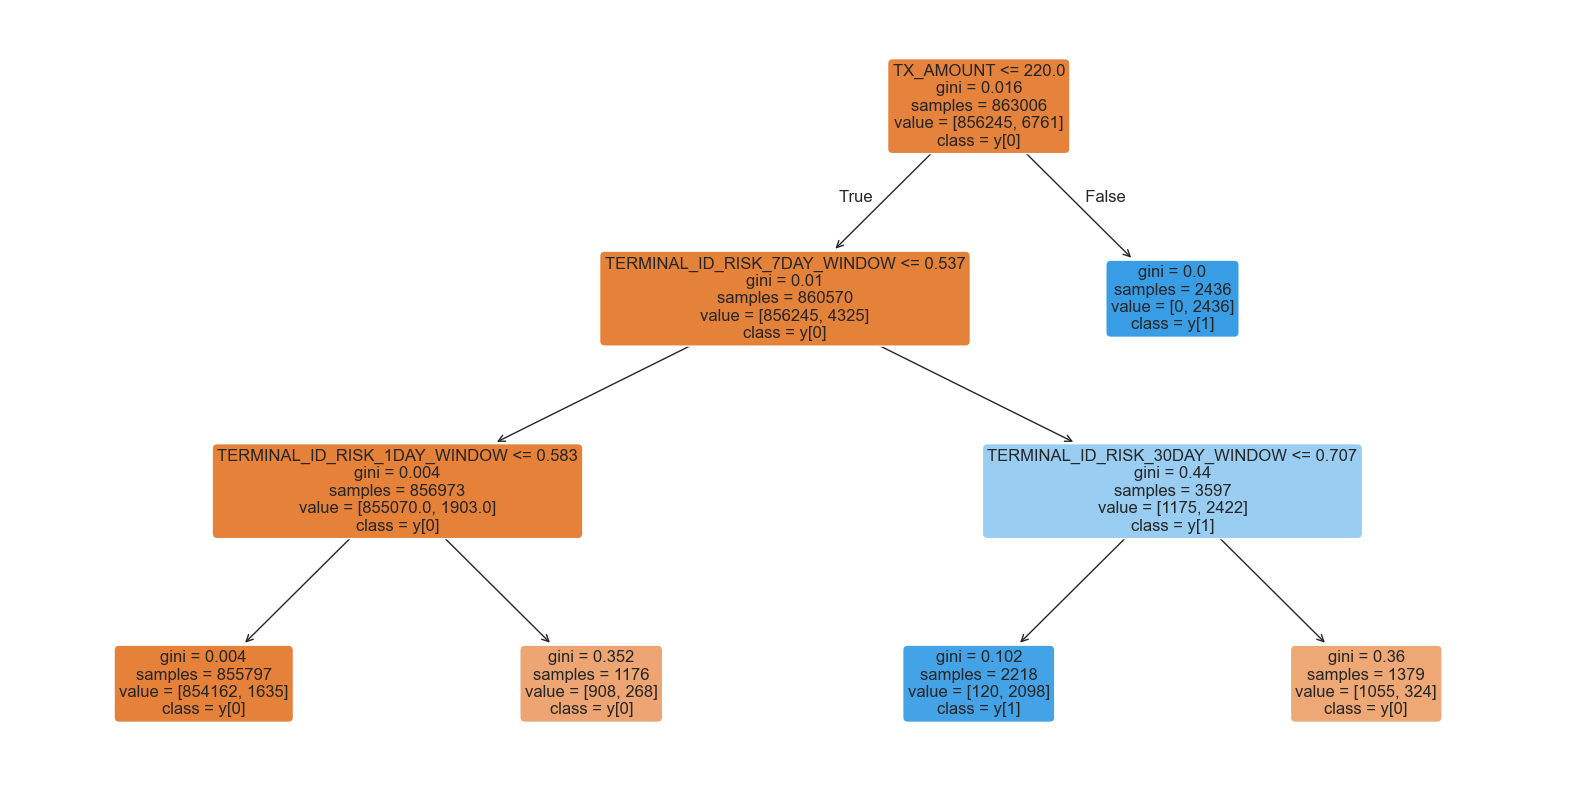

In [178]:
from sklearn import tree

plt.figure(figsize=(20,10)) 
tree.plot_tree(
         classifier, 
         feature_names=input_features, 
         class_names=True,  
         filled=True, 
         rounded=True,
         fontsize=12
 )
plt.show()

## Performance assessment

In [179]:
from sklearn import metrics


def card_precision_top_k_day(df_day,top_k):
    
    # This takes the max of the predictions AND the max of label TX_FRAUD for each CUSTOMER_ID, 
    # and sorts by decreasing order of fraudulent prediction
    df_day = df_day.groupby('CUSTOMER_ID').max().sort_values(by="predictions", ascending=False).reset_index(drop=False)
            
    # Get the top k most suspicious cards
    df_day_top_k=df_day.head(top_k)
    list_detected_compromised_cards=list(df_day_top_k[df_day_top_k.TX_FRAUD==1].CUSTOMER_ID)
    
    # Compute precision top k
    card_precision_top_k = len(list_detected_compromised_cards) / top_k
    
    return list_detected_compromised_cards, card_precision_top_k

def card_precision_top_k(predictions_df, top_k, remove_detected_compromised_cards=True):

    # Sort days by increasing order
    list_days=list(predictions_df['TX_TIME_DAYS'].unique())
    list_days.sort()
    
    # At first, the list of detected compromised cards is empty
    list_detected_compromised_cards = []
    
    card_precision_top_k_per_day_list = []
    nb_compromised_cards_per_day = []
    
    # For each day, compute precision top k
    for day in list_days:
        
        df_day = predictions_df[predictions_df['TX_TIME_DAYS']==day]
        df_day = df_day[['predictions', 'CUSTOMER_ID', 'TX_FRAUD']]
        
        # Let us remove detected compromised cards from the set of daily transactions
        df_day = df_day[df_day.CUSTOMER_ID.isin(list_detected_compromised_cards)==False]
        
        nb_compromised_cards_per_day.append(len(df_day[df_day.TX_FRAUD==1].CUSTOMER_ID.unique()))
        
        detected_compromised_cards, card_precision_top_k = card_precision_top_k_day(df_day,top_k)
        
        card_precision_top_k_per_day_list.append(card_precision_top_k)
        
        # Let us update the list of detected compromised cards
        if remove_detected_compromised_cards:
            list_detected_compromised_cards.extend(detected_compromised_cards)
        
    # Compute the mean
    mean_card_precision_top_k = np.array(card_precision_top_k_per_day_list).mean()
    
    # Returns precision top k per day as a list, and resulting mean
    return nb_compromised_cards_per_day,card_precision_top_k_per_day_list,mean_card_precision_top_k

def performance_assessment(predictions_df, output_feature='TX_FRAUD', 
                           prediction_feature='predictions', top_k_list=[100],
                           rounded=True):
    
    AUC_ROC = metrics.roc_auc_score(predictions_df[output_feature], predictions_df[prediction_feature])
    AP = metrics.average_precision_score(predictions_df[output_feature], predictions_df[prediction_feature])
    
    performances = pd.DataFrame([[AUC_ROC, AP]], 
                           columns=['AUC ROC','Average precision'])
    
    for top_k in top_k_list:
    
        _, _, mean_card_precision_top_k = card_precision_top_k(predictions_df, top_k)
        performances['Card Precision@'+str(top_k)]=mean_card_precision_top_k
        
    if rounded:
        performances = performances.round(3)
    
    return performances

In [180]:
predictions_df=test_df
predictions_df['predictions']=model_and_predictions_dictionary['predictions_test']
    
performance_assessment(predictions_df, top_k_list=[100])

,AUC ROC,Average precision,Card Precision@100
0,0.868,0.705,0.106


The most interpretable metric is the Card Precision@100, which tells us that among the 100 transactions with the highest fraud scores, 10.6% were indeed fraudulent.
Since the percentage of frauds in the test set is only 0.7%, this represents a very strong enrichment: the classifier is effectively concentrating many more true frauds in the top-ranked predictions than would occur by chance.

The interpretation of the AUC ROC and Average Precision is less direct. However, by definition, a random classifier would give an AUC ROC of 0.5, and an Average Precision of 0.007 (equal to the proportion of frauds in the test set). The obtained values are much higher (0.868 for AUC ROC and 0.705 for Average Precision), confirming the classifier’s ability to distinguish fraud from legitimate transactions and to assign higher scores to fraudulent ones in a consistent manner.

## Performances using standard prediction models

Besides the decision tree with depth 3, I trained four other prediction models: 
        
        1- a decision tree with unlimited depth
        
        2- a logistic regression model
        
        3- a random forest
    and a 
        
        4- boosting model: Instead of training one big model, it builds many weak learners (usually shallow decision trees) and combines them to make a strong classifier.
                            Unlike bagging (e.g., Random Forest), boosting builds models sequentially: each new tree focuses on fixing the mistakes of the previous ones.

 These models are the most commonly used in benchmarks in the fraud detection literature

In [187]:
from sklearn.ensemble import GradientBoostingClassifier

classifiers_dictionary={'Logistic regression':sklearn.linear_model.LogisticRegression(random_state=0), 
                        'Decision tree with depth of two':sklearn.tree.DecisionTreeClassifier(max_depth=2,random_state=0), 
                        'Decision tree - unlimited depth':sklearn.tree.DecisionTreeClassifier(random_state=0), 
                        'Random forest':sklearn.ensemble.RandomForestClassifier(random_state=0,n_jobs=-1),
                        'Gradient Boosting': GradientBoostingClassifier(random_state=0),
                       }

fitted_models_and_predictions_dictionary={}

for classifier_name in classifiers_dictionary:
    
    model_and_predictions = fit_model_and_get_predictions(classifiers_dictionary[classifier_name], train_df, test_df, 
                                                                                  input_features=input_features,
                                                                                output_feature=output_feature)
    fitted_models_and_predictions_dictionary[classifier_name]=model_and_predictions

In [192]:
def performance_assessment_model_collection(fitted_models_and_predictions_dictionary, 
                                            transactions_df, 
                                            type_set='test',
                                            top_k_list=[100]):

    performances_list = []  # collect DataFrames in a list
    
    for classifier_name, model_and_predictions in fitted_models_and_predictions_dictionary.items():
        
        predictions_df = transactions_df.copy()  # avoid overwriting original
        predictions_df['predictions'] = model_and_predictions['predictions_' + type_set]
        
        performances_model = performance_assessment(
            predictions_df,
            output_feature='TX_FRAUD',
            prediction_feature='predictions',
            top_k_list=top_k_list
        )
        performances_model.index = [classifier_name]
        
        performances_list.append(performances_model)  
    
    performances = pd.concat(performances_list)
    
    return performances


In [193]:
# performances on test set
df_performances=performance_assessment_model_collection(fitted_models_and_predictions_dictionary, test_df, 
                                                        type_set='test', 
                                                        top_k_list=[100])
df_performances

,AUC ROC,Average precision,Card Precision@100
Logistic regression,0.899,0.739,0.110
Decision tree with depth of two,0.846,0.619,0.100
Decision tree - unlimited depth,0.863,0.506,0.101
Random forest,0.897,0.777,0.110
Gradient Boosting,0.866,0.736,0.107


In [194]:
# performances on training set
df_performances=performance_assessment_model_collection(fitted_models_and_predictions_dictionary, train_df, 
                                                        type_set='train', 
                                                        top_k_list=[100])
df_performances

,AUC ROC,Average precision,Card Precision@100
Logistic regression,0.901,0.739,0.218
Decision tree with depth of two,0.859,0.651,0.207
Decision tree - unlimited depth,1.000,1.000,0.253
Random forest,1.000,1.000,0.253
Gradient Boosting,0.872,0.749,0.213


In [197]:
def execution_times_model_collection(fitted_models_and_predictions_dictionary):

    execution_times = pd.DataFrame() 
    
    for classifier_name, model_and_predictions in fitted_models_and_predictions_dictionary.items():
    
        execution_times_model = pd.DataFrame({
            'Training execution time': [model_and_predictions['training_execution_time']],
            'Prediction execution time': [model_and_predictions['prediction_execution_time']]
        }, index=[classifier_name])
        
        execution_times = pd.concat([execution_times, execution_times_model])
        
    return execution_times

In [198]:
# Execution times
df_execution_times=execution_times_model_collection(fitted_models_and_predictions_dictionary)
df_execution_times

,Training execution time,Prediction execution time
Logistic regression,2.215246,0.066027
Decision tree with depth of two,2.739485,0.081609
Decision tree - unlimited depth,37.035971,0.124586
Random forest,275.275959,1.458917
Gradient Boosting,363.414580,0.966014


The main takeaways in these performance results are

            All prediction models have learned useful fraud patterns from the training data. This can be seen from the AUC ROC on the test set, which is well above 0.5 for all classifiers (ranging from 0.846 to 0.899), and the average precision, which is much higher than the baseline fraud rate of 0.7% (values between 0.506 and 0.777). This confirms that the classifiers are not predicting at random and capture meaningful signals in the data.

            Among the models, Random Forest stands out as the best performer overall, with an AUC ROC of 0.897 and the highest average precision of 0.777 on the test set. Logistic Regression follows closely (AUC ROC 0.899, average precision 0.739), showing that even a simple linear model can perform surprisingly well when fraud patterns are reasonably separable. Gradient Boosting achieves competitive results (AUC ROC 0.866, average precision 0.736), though slightly lower than Random Forest and Logistic Regression.

            The Decision Tree with unlimited depth shows the clearest case of overfitting. On the training set, it achieves perfect scores (AUC ROC = 1, Average Precision = 1), but its test performance drops substantially (AUC ROC 0.863, Average Precision 0.506). This confirms that the model is memorizing the training data rather than generalizing to unseen cases. In contrast, the shallow decision tree (depth=2) performs more conservatively, with lower training performance but relatively stable test results (AUC ROC 0.846, Average Precision 0.619). This demonstrates the trade-off between model complexity and generalization.

            Looking at Card Precision@100, the values on the test set are similar across classifiers (around 10–11%), meaning that all models identify roughly the same proportion of true fraud cases among the top-ranked suspicious cards. However, on the training set, complex models like Random Forest and the unlimited-depth tree reach 25.3%, showing once again their tendency to overfit.

            Execution times show a clear difference between simple and ensemble models. Logistic Regression and shallow trees train in just 2–3 seconds, with predictions taking milliseconds. In contrast, Random Forest (275 seconds) and Gradient Boosting (363 seconds) are significantly slower to train, though still efficient at prediction time. This reflects the computational cost of building large ensembles, which should be weighed against their performance gains.

In summary, Random Forest offers the best balance of performance and generalization on this dataset, Logistic Regression remains a strong and fast baseline, and overly complex models like unlimited-depth trees should be avoided due to overfitting.